# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

import joblib

import warnings
warnings.filterwarnings('ignore')

* Dataset - https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection

# Load and inspect the data

In [2]:
df = pd.read_csv(r'data/bank-transactions.csv')

In [3]:
df.shape

(2512, 16)

In [4]:
df.sample(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
1452,TX001453,AC00257,83.62,2023-06-22 17:18:09,Debit,Raleigh,D000554,202.21.120.44,M069,ATM,48,Doctor,146,1,12652.22,2024-11-04 08:12:06
2412,TX002413,AC00155,91.50,2023-03-27 16:26:42,Debit,Omaha,D000113,168.128.200.203,M033,ATM,47,Doctor,77,1,667.66,2024-11-04 08:07:56
2283,TX002284,AC00373,502.90,2023-09-18 17:13:32,Credit,Fresno,D000384,135.73.131.111,M001,Online,26,Student,141,1,341.24,2024-11-04 08:08:40
1124,TX001125,AC00365,47.60,2023-02-23 18:42:51,Debit,Austin,D000591,163.58.140.206,M026,Online,53,Engineer,115,1,1382.51,2024-11-04 08:08:20
2159,TX002160,AC00216,624.00,2023-02-16 17:34:34,Debit,Houston,D000207,113.137.153.101,M097,Branch,26,Engineer,132,5,4976.18,2024-11-04 08:11:42


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [6]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

* Observations - 
    * Zero missing values
    * `TransactionDate` and `PreviousTransactionDate` columns should be of datetime type
    * Surely we can drop `TransactionID` column. 

In [7]:
df.drop('TransactionID', axis=1, inplace=True)

In [8]:
# Bad -> O(n) operation where n is number of columns in dataset
# for col in df.columns:
#     if 'Date' in col:
#         df[col] = pd.to_datetime(df[col])

In [9]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   AccountID                2512 non-null   object        
 1   TransactionAmount        2512 non-null   float64       
 2   TransactionDate          2512 non-null   datetime64[ns]
 3   TransactionType          2512 non-null   object        
 4   Location                 2512 non-null   object        
 5   DeviceID                 2512 non-null   object        
 6   IP Address               2512 non-null   object        
 7   MerchantID               2512 non-null   object        
 8   Channel                  2512 non-null   object        
 9   CustomerAge              2512 non-null   int64         
 10  CustomerOccupation       2512 non-null   object        
 11  TransactionDuration      2512 non-null   int64         
 12  LoginAttempts            2512 non-

In [11]:
df.duplicated().sum()

np.int64(0)

* Observation - There is output label/column denoting fraud/no fraud, suggesting this is a Unsupervised Problem.

# Exploratory Data Analysis

## Do we need ID columns? - Circle back later

* ID columns have High Cardinality (possibly all are unique values).
* Model memorizes the IDs if we pass it as an input.
* Two ways - either drop them or create a new column denoting their frequency/count -> Gold if there are repeating IDs

In [12]:
id_cols = [col for col in df.columns if 'ID' in col]
id_cols

['AccountID', 'DeviceID', 'MerchantID']

In [13]:
# Check for nunique values in ID columns
n_unq_dict = dict()
for col in id_cols:
    n_unq_dict[col] = df[col].nunique()

n_unq_dict

{'AccountID': 495, 'DeviceID': 681, 'MerchantID': 100}

In [14]:
for col in id_cols:
    df[f'{col}_transaction_count'] = df.groupby(col)[col].transform('count')

In [15]:
df = df.sort_index(axis=1)
df.sample(5)

,AccountBalance,AccountID,AccountID_transaction_count,Channel,CustomerAge,CustomerOccupation,DeviceID,DeviceID_transaction_count,IP Address,Location,LoginAttempts,MerchantID,MerchantID_transaction_count,PreviousTransactionDate,TransactionAmount,TransactionDate,TransactionDuration,TransactionType
48,265.51,AC00296,4,Online,26,Student,D000284,4,93.146.251.20,Denver,1,M023,18,2024-11-04 08:07:24,626.90,2023-11-27 16:45:57,138,Debit
333,2104.82,AC00187,5,Branch,55,Engineer,D000310,7,104.80.232.55,Atlanta,1,M066,34,2024-11-04 08:10:29,118.77,2023-10-02 17:44:05,123,Debit
2113,1983.00,AC00482,6,Branch,25,Student,D000669,6,190.92.63.219,Raleigh,1,M048,26,2024-11-04 08:11:39,15.95,2023-03-14 17:10:00,52,Debit
1996,5399.76,AC00373,9,Branch,74,Retired,D000665,3,12.240.113.200,Oklahoma City,1,M076,21,2024-11-04 08:10:20,14.16,2023-01-09 16:49:07,290,Credit
1693,6118.20,AC00424,5,ATM,52,Retired,D000406,4,158.135.64.240,Nashville,1,M049,24,2024-11-04 08:10:45,127.57,2023-02-27 17:17:05,75,Debit


In [16]:
df.columns

Index(['AccountBalance', 'AccountID', 'AccountID_transaction_count', 'Channel',
       'CustomerAge', 'CustomerOccupation', 'DeviceID',
       'DeviceID_transaction_count', 'IP Address', 'Location', 'LoginAttempts',
       'MerchantID', 'MerchantID_transaction_count', 'PreviousTransactionDate',
       'TransactionAmount', 'TransactionDate', 'TransactionDuration',
       'TransactionType'],
      dtype='object')

* Since I have created the frequency/count of the ID columns we can drop them. 

In [17]:
df.drop(columns=['AccountID', 'DeviceID', 'MerchantID'], axis=1, inplace=True)

In [18]:
df.sample(5)

,AccountBalance,AccountID_transaction_count,Channel,CustomerAge,CustomerOccupation,DeviceID_transaction_count,IP Address,Location,LoginAttempts,MerchantID_transaction_count,PreviousTransactionDate,TransactionAmount,TransactionDate,TransactionDuration,TransactionType
1868,1733.34,5,ATM,53,Retired,4,64.15.0.66,Portland,1,30,2024-11-04 08:11:57,276.16,2023-02-13 16:14:17,71,Credit
1236,6643.24,7,Online,61,Retired,8,193.83.0.183,Seattle,1,23,2024-11-04 08:09:49,701.70,2023-06-30 16:57:37,64,Credit
2478,4500.26,5,ATM,22,Student,3,161.195.172.148,Washington,1,24,2024-11-04 08:09:58,336.84,2023-03-07 17:24:45,100,Debit
922,3466.74,5,Branch,70,Retired,7,159.37.30.154,Columbus,1,27,2024-11-04 08:09:46,21.15,2023-11-20 16:06:10,180,Debit
2153,1419.31,9,Branch,25,Student,7,82.51.236.134,Mesa,1,31,2024-11-04 08:08:06,154.99,2023-08-28 17:07:08,53,Debit


## Feature Engineering - How frequently the fraud occurs?

* One interesting thing would be to check the time since last transcation.
* `TransactionDate` - Day on which the transaction happened.
* `PreviousTransactionDate` - Day on which the last transaction happened.
* To avoid confusion - Rename `PreviousTransactionDate` column to either `LastTranscationDate` or `RecentTransactionDate`.
* Hence, subtract `TransactionDate` from `PreviousTransactionDate` (opposite).

In [19]:
df['time_since_last_transaction_days'] = (df['PreviousTransactionDate'] - df['TransactionDate']).dt.days

In [20]:
df.sample(5)

,AccountBalance,AccountID_transaction_count,Channel,CustomerAge,CustomerOccupation,DeviceID_transaction_count,IP Address,Location,LoginAttempts,MerchantID_transaction_count,PreviousTransactionDate,TransactionAmount,TransactionDate,TransactionDuration,TransactionType,time_since_last_transaction_days
2447,1788.27,7,Online,26,Student,6,186.54.68.246,Miami,1,25,2024-11-04 08:07:56,163.22,2023-04-06 18:06:12,217,Debit,577
1523,10017.11,5,Online,69,Doctor,3,21.28.32.1,Miami,1,22,2024-11-04 08:11:01,3.65,2023-02-13 17:48:36,146,Debit,629
1970,4880.31,9,Online,71,Retired,3,146.250.144.172,Columbus,1,29,2024-11-04 08:06:37,116.89,2023-11-20 16:31:15,226,Debit,349
857,320.25,6,ATM,21,Student,7,96.162.11.85,Phoenix,1,15,2024-11-04 08:07:53,11.81,2023-02-27 16:07:38,131,Debit,615
2163,2366.30,5,Branch,29,Engineer,4,54.252.249.33,Virginia Beach,1,23,2024-11-04 08:10:45,319.50,2023-06-09 16:03:24,69,Credit,513


* Now, it is safe to drop the `TransactionDate` and `PreviousTransactionDate` columns.
* Can also drop `CustomerAge` and `IP Address`.

In [21]:
# df.drop(columns=['TransactionDate', 'PreviousTransactionDate', 'CustomerAge', 'IP Address'], axis=1, inplace=True)
df.drop(columns=['CustomerAge', 'IP Address'], axis=1, inplace=True)

In [22]:
df.dtypes

AccountBalance                             float64
AccountID_transaction_count                  int64
Channel                                     object
CustomerOccupation                          object
DeviceID_transaction_count                   int64
Location                                    object
LoginAttempts                                int64
MerchantID_transaction_count                 int64
PreviousTransactionDate             datetime64[ns]
TransactionAmount                          float64
TransactionDate                     datetime64[ns]
TransactionDuration                          int64
TransactionType                             object
time_since_last_transaction_days             int64
dtype: object

## Numerical Columns

* Histogram + KDE for distribution of data
* Box plot to identify the outliers

In [23]:
num_cols = [col for col in df.columns if df[col].dtype in ('int64', 'float64') and col not in ['AccountID_transaction_count', 'DeviceID_transaction_count', 'MerchantID_transaction_count']]
num_cols

['AccountBalance',
 'LoginAttempts',
 'TransactionAmount',
 'TransactionDuration',
 'time_since_last_transaction_days']

### Skewness in data

In [24]:
df[num_cols].skew()

AccountBalance                      0.601201
LoginAttempts                       5.173491
TransactionAmount                   1.740107
TransactionDuration                 0.599432
time_since_last_transaction_days    0.052764
dtype: float64

* Except `time_since_last_transaction_days` column, all other columns are right skewed.

### Distribution of data & Outliers

In [25]:
def hist_and_scatter(col):

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    n_modes = len(df[col].mode())
    m = ''
    if n_modes == 1:
        m = 'unimodal'
    elif n_modes == 2:
        m = 'bimodal'
    elif n_modes > 2:
        m = 'multi-modal'
    else:
        m = 'no mode'
     
    fig.suptitle(f'Skewness of column - {col} is {df[col].skew().round(4)} and it is {m} data')
    
    # Histogram with KDE 
    sns.histplot(data=df, x=col, stat='density', kde=True, ax=ax[0])
    ax[0].set_title(f'Histogram of column - {col}')
    
    # Boxplot
    sns.boxplot(data=df, x=col, ax=ax[1])
    ax[1].set_title(f'Boxplot of column - {col}')

    plt.tight_layout()
    plt.show()

#### AccountBalance

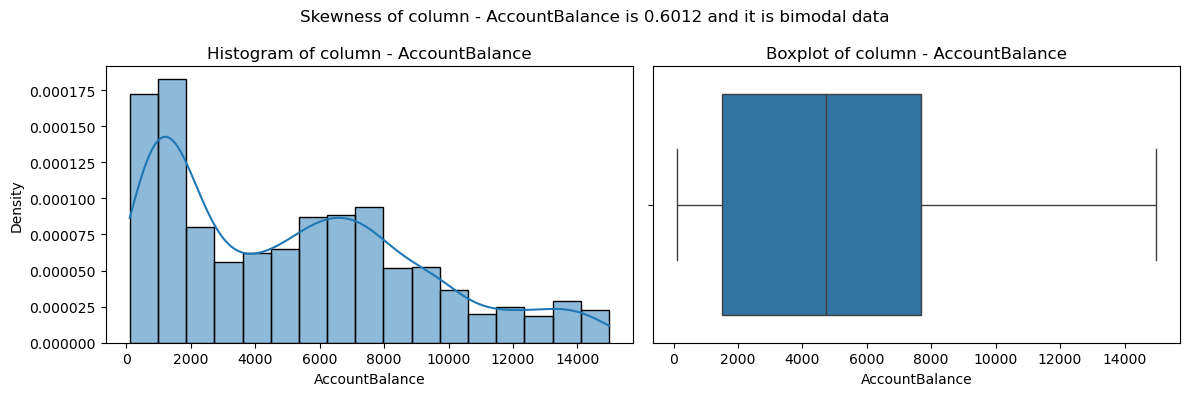

In [26]:
hist_and_scatter('AccountBalance')

#### LoginAttempts

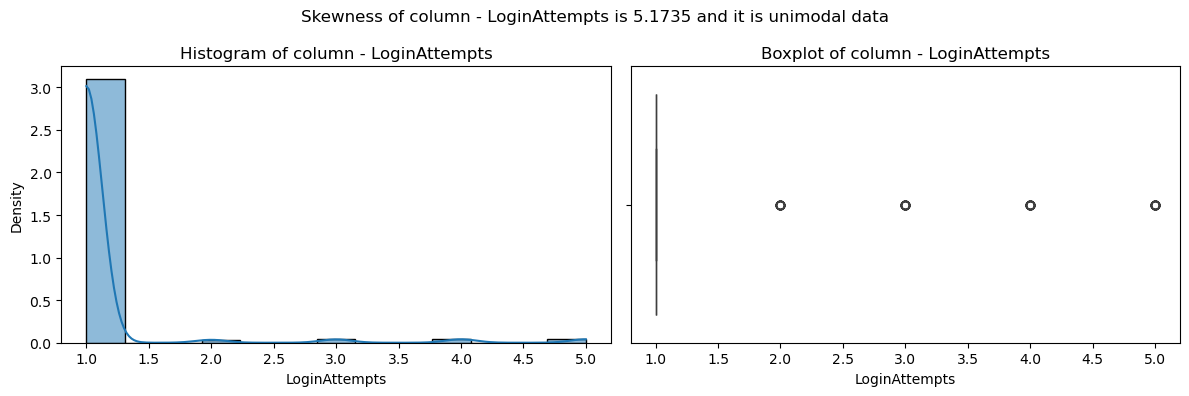

In [27]:
hist_and_scatter('LoginAttempts')

#### TransactionAmount

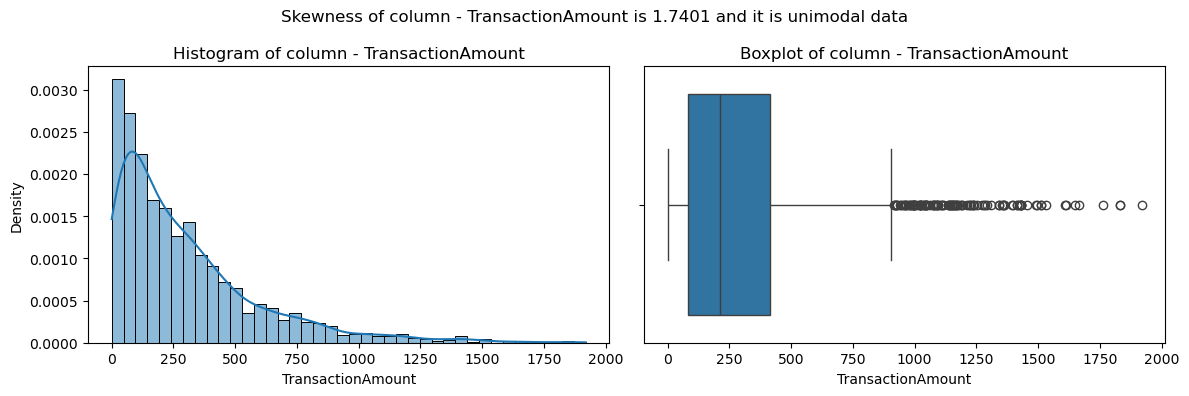

In [28]:
hist_and_scatter('TransactionAmount')

#### TransactionDuration

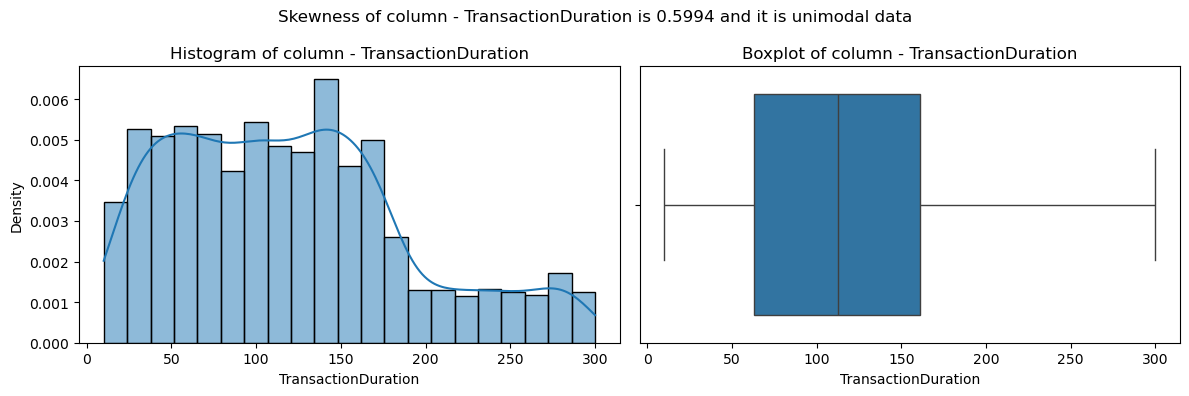

In [29]:
hist_and_scatter('TransactionDuration')

#### time_since_last_transaction_days

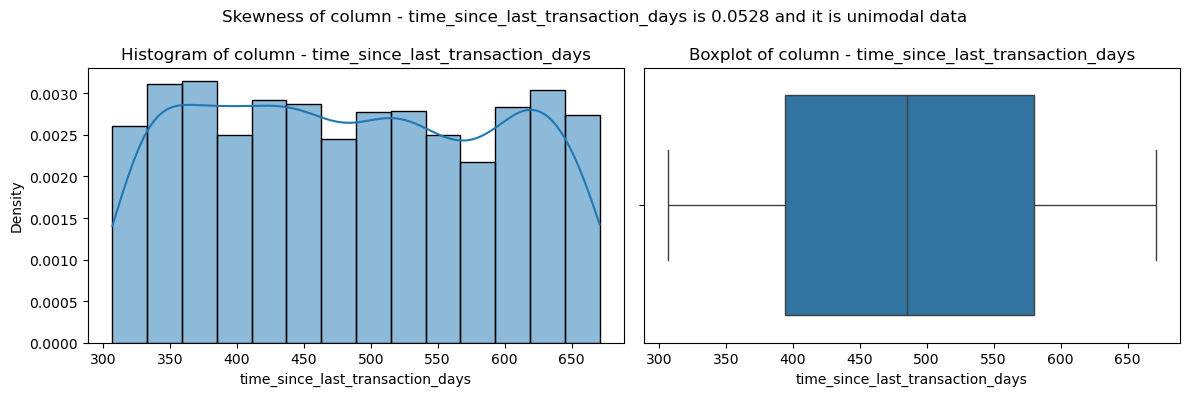

In [30]:
hist_and_scatter('time_since_last_transaction_days')

### Conclusion - Numerical Columns

* Apply either `LogTransform (np.log1p())` or `PowerTransformer (Box-Cox or Yeo-Johnson)` on columns - 
    * `AccountBalance`
    * `LoginAttempts`
    * `TransactionAmount`
    * `TransactionDuration` 

## Categorical Columns

In [31]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
cat_cols

['Channel', 'CustomerOccupation', 'Location', 'TransactionType']

### Class Imbalance - CountPlot - PieChart

In [32]:
# def plot_data(col):

#     # Class Imbalance Table
#     col_df = df[col].value_counts().reset_index()
#     col_df.columns = [col, 'Count']
#     col_df['Percentage'] = col_df['Count'] / col_df['Count'].sum() * 100

#     fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

#     # Count Plot
#     sns.countplot(data=df, x=col, hue=col, palette='pastel', legend=False, ax=ax[0])
#     ax[0].set_title(f'Count Plot of column - {col}')
#     ax[0].tick_params(axis='x', rotation=45)

#     # Pie Chart
#     ax[1].pie(
#         col_df['Count'],
#         labels=col_df[col],
#         autopct='%1.1f%%',
#         colors=sns.color_palette('pastel')
#     )
#     ax[1].set_title(f'Pie Chart of column - {col}')

#     plt.tight_layout()
#     plt.show()

def plot_data(col):

    # Class Imbalance Table
    category_order = df[col].dropna().unique()
    col_df = (df[col].value_counts().reindex(category_order).reset_index())
    col_df.columns = [col, 'Count']
    col_df['Percentage'] = col_df['Count'] / col_df['Count'].sum() * 100

    palette = sns.color_palette('pastel', len(category_order))
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    # Count Plot
    sns.countplot(data=df, x=col, order=category_order, palette=palette,ax=ax[0])
    ax[0].set_title(f'Count Plot of column - {col}')
    ax[0].tick_params(axis='x', rotation=45)

    # Pie Chart
    ax[1].pie(col_df['Count'], labels=category_order, autopct='%1.1f%%', colors=palette)
    ax[1].set_title(f'Pie Chart of column - {col}')

    plt.tight_layout()
    plt.show()

#### Channel

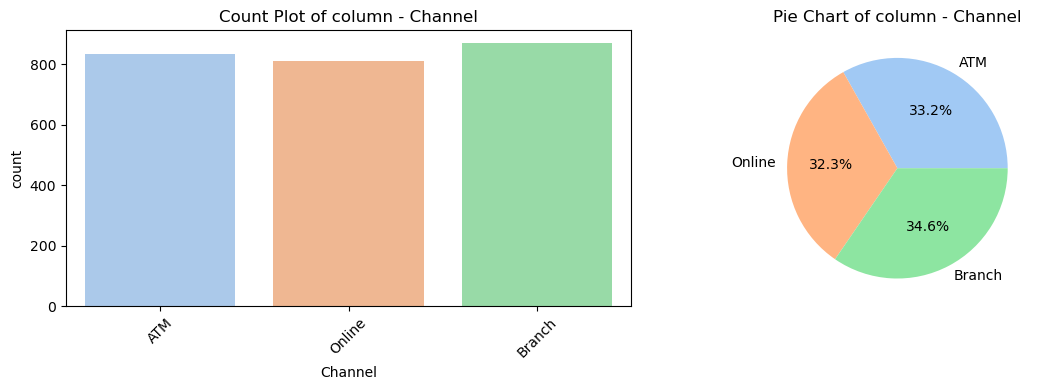

In [33]:
plot_data('Channel')

#### CustomerOccupation

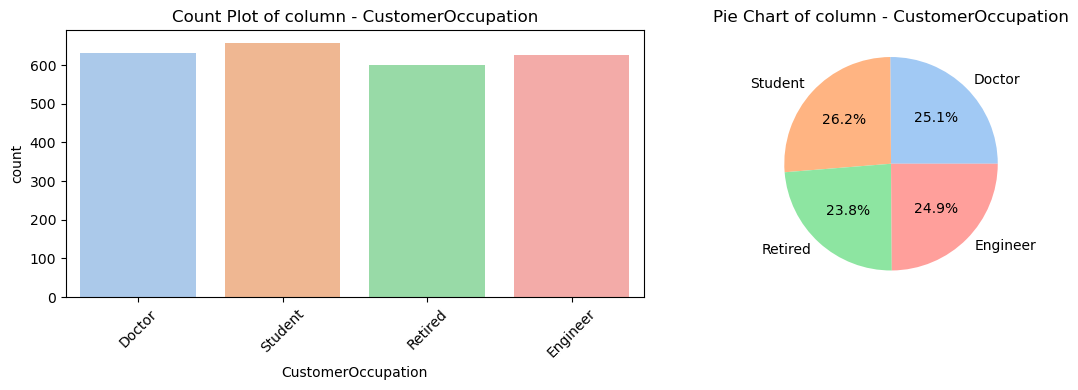

In [34]:
plot_data('CustomerOccupation')

#### Location

In [35]:
# Class Imbalance Table
loc_df = df['Location'].value_counts().reset_index()
loc_df.columns = ['Location', 'Count']
loc_df['Percentage'] = loc_df['Count'] / loc_df['Count'].sum() * 100
loc_df

,Location,Count,Percentage
0,Fort Worth,70,2.786624
1,Los Angeles,69,2.746815
2,Oklahoma City,68,2.707006
3,Charlotte,68,2.707006
4,Philadelphia,67,2.667197
5,Tucson,67,2.667197
6,Omaha,65,2.587580
7,Miami,64,2.547771
8,Memphis,63,2.507962
9,Detroit,63,2.507962


#### TransactionType

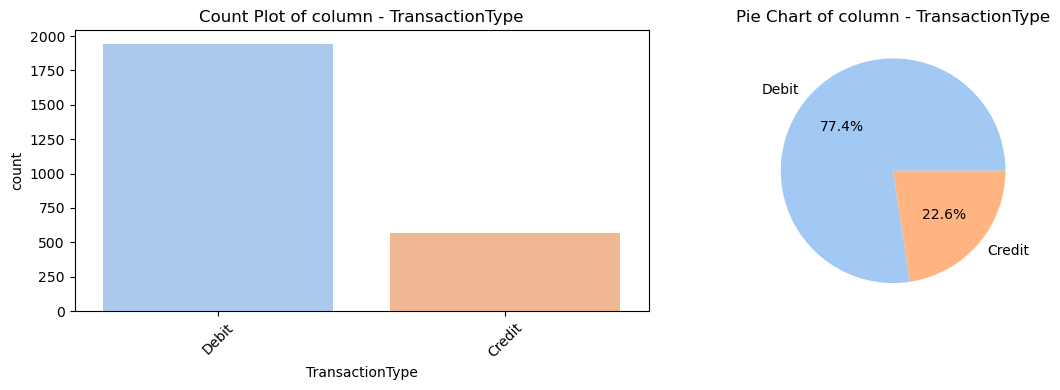

In [36]:
plot_data('TransactionType')

### Conclusion - Categorical Columns

* For columns - `Channel`, `CustomerOccupation` and `Location`, the class proportions appear balanced, with no significant deviations.
* But for column - `TransactionType`, there is significant class dis-proportion.
* Since there is no natural ordering b/w the classes in these columns, use `OneHotEncoder` to encode the data.

# Pipelines

## Numerical

In [37]:
num_pipeline = Pipeline(
    steps = [
        ('yeo-johnson', PowerTransformer()) # This also does standardization
    ],
    verbose=True
)

## Categorical

In [38]:
cat_pipeline = Pipeline(
    steps = [
        ('onehot', OneHotEncoder(drop='first', sparse_output=False))
    ], 
    verbose=True
)

## Column Transformer

In [39]:
num_cols

['AccountBalance',
 'LoginAttempts',
 'TransactionAmount',
 'TransactionDuration',
 'time_since_last_transaction_days']

In [40]:
cat_cols

['Channel', 'CustomerOccupation', 'Location', 'TransactionType']

In [41]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ],
    verbose=True,
    verbose_feature_names_out=True,
    n_jobs=-1,
    remainder='passthrough'
)

## Isolation Forest

In [42]:
iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42, n_jobs=-1)

In [43]:
pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('isolationForest', iso)
    ],
    verbose=True
)

# Train Test Split

* Wait, I don't have labels here? How do I split? -> There's a columns `TransactionDate` on which you can split the data.
* For anomaly detection, we assume - most data is normal. So training on full dataset is not “wrong”. But splitting is cleaner engineering practice.

In [44]:
# Sort the data on TransactionDate
df = df.sort_values('TransactionDate')

split_index = int(0.8 * len(df)) # 80% index point

# Train and Test split (num_cols + cat_cols)
train_df = df[num_cols + cat_cols].iloc[:split_index]
test_df = df[num_cols + cat_cols].iloc[split_index:]

In [45]:
train_df.shape

(2009, 9)

In [46]:
test_df.shape

(503, 9)

# Fit/Train the model

In [47]:
pipeline.fit(train_df)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   2.0s
[Pipeline] ... (step 2 of 2) Processing isolationForest, total=   0.5s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('yeo-johnson',
                                                                   PowerTransformer())],
                                                           verbose=True),
                                                  ['AccountBalance',
                                                   'LoginAttempts',
                                                   'TransactionAmount',
                                                   'TransactionDuration',
                                                   'time_since_last_transaction_days']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))],
                                                           verbose=True),
                                                  ['Channel',
                                                   'CustomerOccupation',
                                                   'Location',
                                                   'TransactionType'])],
                                   verbose=True)),
                ('isolationForest',
                 IsolationForest(contamination=0.02, n_estimators=300,
                                 n_jobs=-1, random_state=42))],
         verbose=True)

# Prediction

In [48]:
train_df['anomaly_label'] = pipeline.predict(train_df)
train_df['anomaly_score'] = pipeline.decision_function(train_df)

In [49]:
test_df['anomaly_label'] = pipeline.predict(test_df)
test_df['anomaly_score'] = pipeline.decision_function(test_df)

# Interpretation

In [50]:
train_df['anomaly_label'].value_counts(normalize=True).reset_index(name='Proportion')

,anomaly_label,Proportion
0,1,0.979592
1,-1,0.020408


In [51]:
test_df['anomaly_label'].value_counts(normalize=True).reset_index(name='Proportion')

,anomaly_label,Proportion
0,1,0.970179
1,-1,0.029821


* Train - 
    * Normal (1): 97.96%
    * Anomaly (-1): 2.04%

* Test -
    * Normal (1): 97.02%
    * Anomaly (-1): 2.98% (contamination was set to 2%) .

Here's what happned - 
* Isolation Forest, forces ~2% anomalies in training
* Learns a threshold internally
* Applies same threshold to test

Now test shows ~3% anomalies, which is good (model has generalized).

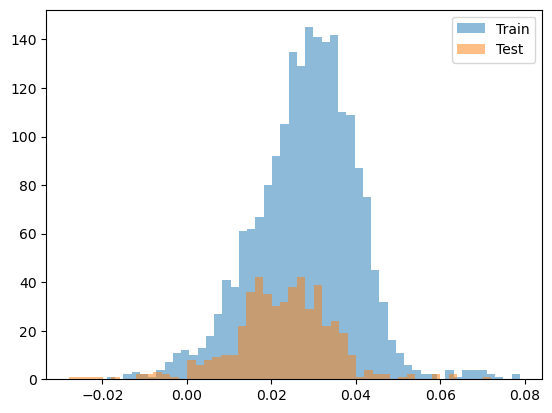

In [52]:
plt.hist(train_df['anomaly_score'], bins=50, alpha=0.5, label='Train')
plt.hist(test_df['anomaly_score'], bins=50, alpha=0.5, label='Test')
plt.legend()
plt.show()

In [53]:
test_df.describe()

,AccountBalance,LoginAttempts,TransactionAmount,TransactionDuration,time_since_last_transaction_days,anomaly_label,anomaly_score
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,5219.607932,1.105368,298.514175,121.675944,342.170974,0.940358,0.022598
std,3936.890201,0.541901,301.576893,73.282434,19.959186,0.340526,0.011998
min,125.850000,1.000000,0.260000,10.000000,307.000000,-1.000000,-0.027921
25%,1487.140000,1.000000,77.700000,63.000000,326.000000,1.000000,0.016130
50%,5126.650000,1.000000,208.040000,111.000000,342.000000,1.000000,0.023121
75%,7809.385000,1.000000,400.195000,165.000000,359.000000,1.000000,0.030285
max,14977.990000,5.000000,1647.740000,300.000000,377.000000,1.000000,0.071970


In [54]:
test_df.sort_values('anomaly_score').head(1)

,AccountBalance,LoginAttempts,TransactionAmount,TransactionDuration,time_since_last_transaction_days,Channel,CustomerOccupation,Location,TransactionType,anomaly_label,anomaly_score
1213,7816.41,5,1192.2,103,318,Branch,Retired,Jacksonville,Credit,-1,-0.027921


* This is how the model (Isolation Forest) thought - 
    * TransactionAmount - 1192.2 is above the average transaction amount 298.51.
    * LogingAttempts - 5 which is relatively high
    * time_since_last_transaction_days - 318 ~ almost 1 year
    * TransactionDuration - 103 seconds which is slightly lower than average transaction duration 121.67 seconds (might be network issue lol 😆)

**Conclusion - So a person who's Retired becomes active almost after an year, does 5 LoginAttempts, does a transaction of 1192.2 and takes 103 seconds for it. Umm, seems odd, let me mark it as anomalous.** 

In [55]:
test_df.sort_values('anomaly_score', ascending=False).head(1)

,AccountBalance,LoginAttempts,TransactionAmount,TransactionDuration,time_since_last_transaction_days,Channel,CustomerOccupation,Location,TransactionType,anomaly_label,anomaly_score
1650,8019.89,1,54.34,46,314,ATM,Doctor,Albuquerque,Debit,1,0.07197


* This is how the model (Isolation Forest) thought - 
    * TransactionAmount - 54.34 is well below the median (50 %) transaction amount.
    * LogingAttempts - 1 which is fine
    * time_since_last_transaction_days - 314 ~ almost 1 year
    * TransactionDuration - 46 seconds which is well below the average transaction duration 121.67 seconds (pretty fast internet 😊)

**Conclusion - So a person who's Doctor becomes active almost after an year, in 1 LoginAttempts, does a transaction of 54.34 and takes 46 seconds for it. Nothing seems odd, let me mark it as normal.** 

# Prediction on new data

In [56]:
new_data = pd.DataFrame([
    
    # Likely Normal
    {
        "AccountBalance": 5200,
        "CustomerAge": 35,
        "LoginAttempts": 1,
        "TransactionAmount": 120,
        "TransactionDuration": 45,
        "time_since_last_transaction_days": 7,
        "Channel": "Online",
        "CustomerOccupation": "Engineer",
        "Location": "San Diego",
        "TransactionType": "Debit"
    },
    
    # Suspicious: Long inactivity + high amount + multiple logins
    {
        "AccountBalance": 8000,
        "CustomerAge": 68,
        "LoginAttempts": 5,
        "TransactionAmount": 2500,
        "TransactionDuration": 130,
        "time_since_last_transaction_days": 365,
        "Channel": "Branch",
        "CustomerOccupation": "Retired",
        "Location": "Jacksonville",
        "TransactionType": "Credit"
    },

    # Suspicious: Very high login attempts
    {
        "AccountBalance": 1500,
        "CustomerAge": 22,
        "LoginAttempts": 8,
        "TransactionAmount": 400,
        "TransactionDuration": 60,
        "time_since_last_transaction_days": 3,
        "Channel": "Online",
        "CustomerOccupation": "Student",
        "Location": "Memphis",
        "TransactionType": "Debit"
    },

    # Borderline: High amount but recent activity
    {
        "AccountBalance": 10000,
        "CustomerAge": 40,
        "LoginAttempts": 1,
        "TransactionAmount": 1800,
        "TransactionDuration": 55,
        "time_since_last_transaction_days": 2,
        "Channel": "ATM",
        "CustomerOccupation": "Engineer",
        "Location": "Los Angeles",
        "TransactionType": "Credit"
    },

    # Suspicious: Very low balance + large transaction
    {
        "AccountBalance": 150,
        "CustomerAge": 29,
        "LoginAttempts": 3,
        "TransactionAmount": 900,
        "TransactionDuration": 90,
        "time_since_last_transaction_days": 180,
        "Channel": "Online",
        "CustomerOccupation": "Student",
        "Location": "Fort Worth",
        "TransactionType": "Debit"
    }

])

In [57]:
new_data

,AccountBalance,CustomerAge,LoginAttempts,TransactionAmount,TransactionDuration,time_since_last_transaction_days,Channel,CustomerOccupation,Location,TransactionType
0,5200,35,1,120,45,7,Online,Engineer,San Diego,Debit
1,8000,68,5,2500,130,365,Branch,Retired,Jacksonville,Credit
2,1500,22,8,400,60,3,Online,Student,Memphis,Debit
3,10000,40,1,1800,55,2,ATM,Engineer,Los Angeles,Credit
4,150,29,3,900,90,180,Online,Student,Fort Worth,Debit


In [58]:
new_data['anomaly_label'] = pipeline.predict(new_data)
new_data['anomaly_score'] = pipeline.decision_function(new_data)

new_data.sort_values('anomaly_score')

,AccountBalance,CustomerAge,LoginAttempts,TransactionAmount,TransactionDuration,time_since_last_transaction_days,Channel,CustomerOccupation,Location,TransactionType,anomaly_label,anomaly_score
1,8000,68,5,2500,130,365,Branch,Retired,Jacksonville,Credit,-1,-0.033248
4,150,29,3,900,90,180,Online,Student,Fort Worth,Debit,-1,-0.005357
2,1500,22,8,400,60,3,Online,Student,Memphis,Debit,-1,-0.005039
3,10000,40,1,1800,55,2,ATM,Engineer,Los Angeles,Credit,1,0.001045
0,5200,35,1,120,45,7,Online,Engineer,San Diego,Debit,1,0.011297


# Save the Model

In [59]:
joblib.dump(pipeline, "fraud_isolation_forest_pipeline.pkl")

['fraud_isolation_forest_pipeline.pkl']

In [60]:
loaded_pipeline = joblib.load("fraud_isolation_forest_pipeline.pkl")
loaded_pipeline.predict(new_data)

array([ 1, -1, -1,  1, -1])